You want to build n new buildings in a city. The new buildings will be built in a line and are labeled from 1 to n.

However, there are city restrictions on the heights of the new buildings:

    The height of each building must be a non-negative integer.
    The height of the first building must be 0.
    The height difference between any two adjacent buildings cannot exceed 1.

Additionally, there are city restrictions on the maximum height of specific buildings. These restrictions are given as a 2D integer array restrictions where restrictions[i] = [idi, maxHeighti] indicates that building idi must have a height less than or equal to maxHeighti.

It is guaranteed that each building will appear at most once in restrictions, and building 1 will not be in restrictions.

Return the maximum possible height of the tallest building.

 

Example 1:

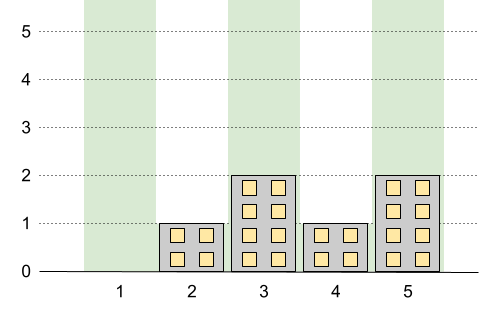

Input: n = 5, restrictions = [[2,1],[4,1]]
Output: 2
Explanation: The green area in the image indicates the maximum allowed height for each building.
We can build the buildings with heights [0,1,2,1,2], and the tallest building has a height of 2.

Example 2:

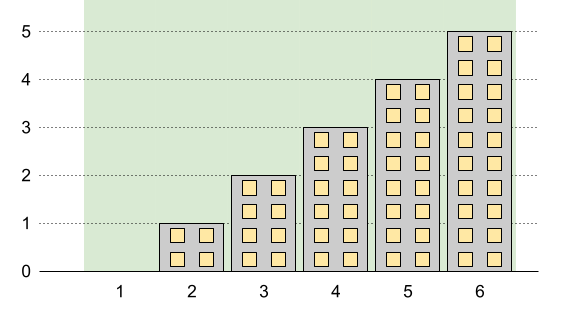

Input: n = 6, restrictions = []
Output: 5
Explanation: The green area in the image indicates the maximum allowed height for each building.
We can build the buildings with heights [0,1,2,3,4,5], and the tallest building has a height of 5.

Example 3:

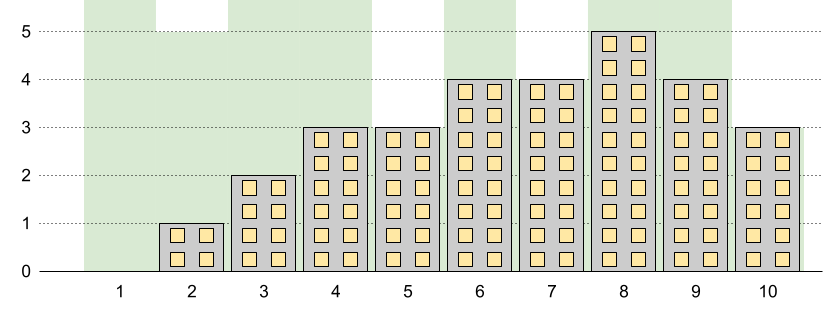

Input: n = 10, restrictions = [[5,3],[2,5],[7,4],[10,3]]
Output: 5
Explanation: The green area in the image indicates the maximum allowed height for each building.
We can build the buildings with heights [0,1,2,3,3,4,4,5,4,3], and the tallest building has a height of 5.

 

Constraints:

    2 <= n <= 109
    0 <= restrictions.length <= min(n - 1, 105)
    2 <= idi <= n
    idi is unique.
    0 <= maxHeighti <= 109


In [ ]:
class Solution:
    def maxBuilding(self, n: int, restrictions: List[List[int]]) -> int:
        r = restrictions
        # Add restriction (1, 0)
        r.append([1, 0])
        r.sort()

        # Add restriction (n, n-1)
        if r[-1][0] != n:
            r.append([n, n - 1])

        m = len(r)

        # Pass restrictions from left to right
        for i in range(1, m):
            r[i][1] = min(r[i][1], r[i - 1][1] + (r[i][0] - r[i - 1][0]))
        # Pass restrictions from right to left
        for i in range(m - 2, 0, -1):
            r[i][1] = min(r[i][1], r[i + 1][1] + (r[i + 1][0] - r[i][0]))

        ans = 0
        for i in range(m - 1):
            # Calculate the maximum height of the buildings between r[i][0] and r[i][1]
            best = ((r[i + 1][0] - r[i][0]) + r[i][1] + r[i + 1][1]) // 2
            ans = max(ans, best)

        return ans